In [1]:
import pandas as pd
import numpy as np
import datetime as dt

# 시계열 데이터 생성

사용자는 python에서 제공하는 날짜와 시간 데이터 타입과 클래스를 인덱스로 설정하고 이와 연관된 데이터를 입력하여 시계열 데이터를 직접 만들 수 있다. 하지만 요즘같은 세상에 그런 데이터를 하나 하나 입력하여 생성한다는 것은 매우 비효율적인 방법임에 틀림없다. 특히 요즘같이 빅데이터를 다루는 시기에 데이터를 직접 입력해서 만드는 것은 상상도 할 수 없는 일이고, 만약 그렇게 만들 수 있다고 해도 간단한 테스트용이나 1회성 데이터일 것이다. 따라서 대부분의 시계열 데이터는 대량의 데이터가 기록된 데이터베이스, 파일 등에서 추출하여 임포트하는 것이 일반적이다. 또 하나의 방법은 다양한 기관이나 웹에서 공식적으로 제공하는 API를 사용하거나 python에서 제공하는 웹 데이터베이스 접근 라이브러리를 사용하여 데이터를 가져올수도 있다. 

이번 장에서는 이 책 전반에서 사용할 시계열 데이터 세트를 만들기 위해 월드뱅크에서 제공하는 웹 데이터베이스에 접근하는 라이브러리를 사용하는 데이터 추출 방법과 엑셀과 CSV 파일을 사용해 데이터를 추출하는 하는 방법을 사용하여 시계열 데이터를 생성하는 방법에 대해 설명한다. 

## 데이터 스크래핑 라이브러리

python에서 인터넷과 웹에서 공개된 데이터를 가져오는 라이브러리를 웹 스크래핑(Web Scraping) 라이브러리 혹은 데이터 스크래핑 라이브러리라고 한다. 이 스크래핑 라이브러리는 인터넷에 게시된 html, xml, json 파일을 읽어 불러들이거나 데이터베이스 보유 사이트에서 제공하는 API를 통해 데이터를 불러들이는 기능을 제공한다. 인터넷에 게시된 html, xml, json 등의 데이터를 불러들이는 라이브러리는 매개변수로 전달된 해당 데이터가 게시된 사이트와 데이터 형식을 사용해 해당 데이터를 읽어들이기 때문에 사용 범위가 매우 넓고 다양한 소스의 데이터를 엑세스 할 수 있다는 점에서 장점이 있다. 하지만 웹에 게시된 형태로 데이터를 다운로드 받기 때문에 표준화 되어 있지 않은 경우가 많아 데이터를 불러들인 후 후처리 작업이 필요다는 단점이 있다. 특히 과도한 스크래핑은 자칫 해당 작업이 블로킹 되는 경우도 있어 주의가 필요하다.  반면 데이터베이스 보유 사이트에서 제공하는 API를 사용하는 라이브러리는 미리 표준화된 데이터를 다운로드 받기 때문에 후처리에 드는 노력이 비교적 적고 데이터 갱신에 대한 오류 발생 가능성이 적다는 장점이 있지만 해당 API의 접근 권한을 미리 받아야 하는 경우가 많고 사용자가 제공하는 데이터에 한정된다는 단점이 있다. 

웹에 게시된 데이터를 스크래핑하는데 많이 사용되는 python 라이브러리는 다음과 같다. 

<div class="alert alert-success">
    
- requests : html 문서를 가져올 때 사용하는 패키지로써, 웹 크롤링이나 웹 스크래핑에 매우 많이 사용되는 python 라이브러리이다. HTML 문서를 파싱하고 CSS 선택자를 이용하여 웹 문서에서 데이터를 추출하여 사용할 수 있는데, requests.get(), requests.post(), requests.put(), requests.delete()와 같이  html 문서를 작성하는데 사용하는 문법과 유사한 문법을 사용함으로서 다루기가 쉽다는 장점이 있다. 
- Selenium : 브라우저 자동화 도구로, 동적 웹 페이지에서 데이터를 스크래핑하는 데에 주로 사용되는 라이브러리이다. 
- Beautiful Soup: HTML과 XML 문서를 파싱하고 데이터를 추출하기 위한 라이브러리이다.
- urllib: URL을 다루는 라이브러리로써, HTTP 요청을 보내는 데에 사용된다.
- Scrapy: 대규모 웹 스크래핑에 적합한 라이브러리로, 분산 스크래핑과 스크래핑한 데이터를 처리하는 기능을 제공한다.
</div>
    
또한 API를 사용하여 데이터를 스크래핑하는데 많이 사용되는 python라이브러리는 다음과 같다. 

<div class="alert alert-success">
    
- pandas_datareader: pandas_datareader는 다양한 웹 데이터 소스에서 데이터를 가져오는 pandas의 서브 라이브러리로 World Bank, OECD, FRED와 같은 글로벌 데이터 소스의 API 방식을 지원한다.
- pandas-gbq: pandas-gbq는 Google BigQuery에서 데이터를 가져오는 pandas의 서브 라이브러리이다.
- quandl: 많은 해외 국가의 금융 데이터를 제공하는 데이터 마켓인 https://data.nasdaq.com/ 에서 제공하는 API를 사용하여 데이터를 가져오는 라이브러리이다. 세계 각국 주식 시장의 주식 가격, 환율, 기타 금융 데이터가 제공된다.
- alpha_vantage: https://www.alphavantage.co/ 에서 제공하는 다양한 금융 데이터를 가져오는 라이브러리로, 암호화폐, 주식, 환율 등을 지원한다.
- yfinance: Yahoo Finance에서 제공하는 주식 가격 데이터를 가져오는 라이브러리이다.
- covid19py: COVID-19에 대한 데이터를 가져오는 라이브러리로 Johns Hopkins University와 WHO(Wolrd Health Organization)에서 공식적으로 공표하는 데이터를 지원한다.
- IMDbPY: 인터넷 영화 데이터베이스인 IMDb의 데이터를 가져올 수 있는 라이브러리로써, 영화 정보, 출연 배우 정보 등 다양한 데이터를 가져올 수 있다.
</div>

이 외에도 많은 파이썬 라이브러리들이 다양한 데이터를 가져오는 데 사용되는데 이번 장에서는 World bank 데이터를 가져오는 방법을 알아본다. 

월드 뱅크는 빈곤 해소를 목적으로 세계은행(世界銀行)은 유엔 산하의 국제 금융기관이다. 월드 뱅크에서는 전세계 여러 나라의 경제 지표를 비롯하여 교육, 기후변화, 환경, 노동, 건강 등의 20여개 이상의 분야에 걸친 2000여개 이상의 다양한 사회 지표를 제공하고 있다. 월드 뱅크 홈페이지를 통해 직접 지표를 검색하여 그래프를 사용하거나 해당 데이터를 엑셀, CSV 파일등으 다운로드 검색 방식 외에도 국가별 자료를 확인할 수도 있고 주제별로 모아진 지표를 한꺼번에 확인하고 필요한 지표를 선택하여 조회하거나, 해당 데이터를 CSV, XML, Excel 파일로 다운로드할 수 있다. 또 월드 뱅크에서 제공하는 API를 사용하여 해당 데이터를 바로 pandas 데이터프레임으로 가져올 수도 있다. 

월드 뱅크 데이터를 가져오는 방식은 여러가지가 있으나 여기서는 pandas_datareader 라이브러리를 사용한다.

pandas_datareader를 사용하기 위해서는 먼저 해당 라이브러리를 설치하여야 하는데 다음과 같이 설치할 수 있다.

<div class="alert alert-info" role="alert">
> pip install pandas_datareader
</div>

다음은 주요 10개 국가와 대륙의 1960년부터 2022년까지의 인구 1인당 GDP(2015년 물가 조정치)를 가져오는 코드이다.  

In [2]:
from pandas_datareader import wb

df_GDP = wb.download(indicator='NY.GDP.PCAP.KD', country=['KOR', 'USA', 'FRA', 'JPN', 'GBR', 'DEU', 'ITA', 'CAN', 'WLD', 'EU'], start=1960, end=2022)
df_GDP = df_GDP.unstack().T.reset_index(0).drop(['level_0'], axis = 1)
df_GDP.index = pd.to_datetime(df_GDP.index)

print(df_GDP.info())

c:\python\ts_python_310\lib\site-packages\pandas_datareader\wb.py:592: UserWarning: Non-standard ISO country codes: EU, WLD
  warnings.warn(


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 62 entries, 1960-01-01 to 2021-01-01
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Canada          25 non-null     float64
 1   European Union  52 non-null     float64
 2   France          62 non-null     float64
 3   Germany         52 non-null     float64
 4   Italy           62 non-null     float64
 5   Japan           62 non-null     float64
 6   Korea, Rep.     62 non-null     float64
 7   United Kingdom  62 non-null     float64
 8   United States   62 non-null     float64
 9   World           62 non-null     float64
dtypes: float64(10)
memory usage: 5.3 KB
None


앞의 시계열 데이터를 보면 데이터프레임의 인덱스로 datetimeindex 클래스의 데이터를 사용하고 있고 넓은 형태의 데이터프레임으로 구성되어 있다. 이 데이터를 간략히 시각화해보면 다음과 같다. 

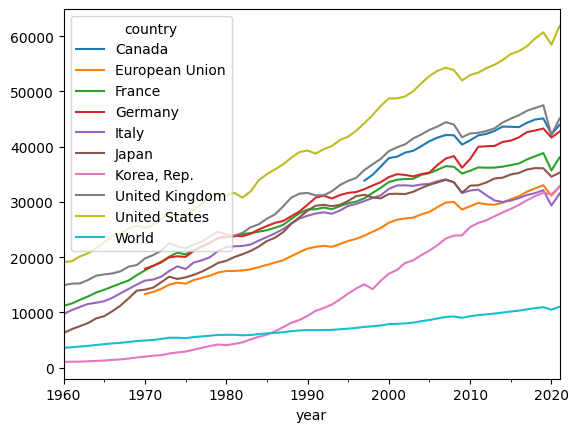

In [3]:
import matplotlib.pyplot as plt

df_GDP.plot()
plt.show()

## 파일 데이터의 사용

시계열 데이터 뿐 아니라 데이터 분석에 사용되는 데이터를 생성하는데 보편적으로 사용되는 방식은 엑셀, CSV, text 파일 등으로 보유하고 있는 데이터를 불러 읽어들이는 방법이다. python의 pandas에서 파일 데이터를 불러 읽어들이는데 가장 보편적으로 사용되는 함수가 `read_csv()`와 `read_excel()`이다. 파일명에서도 나타나듯이 `read_csv()`는 텍스트 파일 형태의 CSV(Comma Seperated Values) 파일을 읽어들이는 함수이고 `read_excel()`은 Microsoft Excel 파일을 읽어들이는 함수이다. 이 함수들을 사용하여 시계열 데이터를 읽어들을 때는 데이터 파일명 외에 다음의 두 개의 매개변수가 사용된다.

<div class="alert alert-success">
    
- parse_dates : 파일에 기록된 데이터 열 중에 날짜나 시간으로 파싱되는 데이터 열의 리스트를 지정, ISO 8601 형식(YYYY-MM-DD HH:MM:SS)으로 지정된 열에서 날짜 시간 개체로 변환
- index_col : 인덱스로 사용될 열을 지정, 시계열 데이터로 사용되기 위해서는 parse_date로 지정된 열의 리스트 중 하나를 지정
</div>

다음은 우리나라 통계청의 kosis에서 제공하는 월별 국가별 수출입 현황 통계의 엑셀 파일을 pandas의 `read_excel()`을 사용하여 불러들이는 코드이다. 이 파일에서는 특정 열에 날짜가 기록되지 않고 월별 데이터가 각 열로 배치된 형태이기 때문에 'parse_dates'와 'index_col'을 사용하지 않았다. 따라서 날짜 열을 만들기 위해 데이터프레임의 열과 행을 전치시켰고 이 후 인덱스 열을 `to_datetime()`을 사용해 datetimeindex로 전환하였다. 

In [4]:
df_import = pd.read_excel('./국가별_수출입현황_20230218214213.xlsx') 
df_import['항목'] = df_import['항목'].str.strip("(천불) ")
df_import.rename(columns={'국가별(1)': '국가', '항목':'항목'}, inplace=True)
df_import = df_import.set_index(['국가', '항목']).transpose()
df_import.index = pd.to_datetime(df_import.index)
df_import.head()

국가               중국                        미국                        일본  \
항목             수출금액     수입금액    무역수지     수출금액     수입금액    무역수지     수출금액   
2000-01-01  1235215  1008166  227050  2609788  2217025  392763  1551722   
2000-02-01  1273117   834291  438827  2554310  2241520  312790  1518845   
2000-03-01  1437377  1125348  312029  2946821  2607380  339441  1783565   
2000-04-01  1366877  1032362  334514  2698030  2570158  127872  1582708   
2000-05-01  1663241  1066610  596630  3167181  2634243  532939  1671040   

국가                                홍콩  ...    싱가포르      인도                \
항목             수입금액     무역수지    수출금액  ...    무역수지    수출금액   수입금액   무역수지   
2000-01-01  2357231  -805509  782349  ...  145743  126874  74035  52839   
2000-02-01  2430091  -911246  823990  ...  114522  144711  62395  82316   
2000-03-01  2935699 -1152135  911648  ...  246557  143327  84936  58390   
2000-04-01  2814895 -1232187  863243  ...  134400  100741  91855   8886   
2000-05-01  2627642  -956602  887081  ...  206414  106458  82600  23858   

국가              독일                    멕시코                 
항목            수출금액    수입금액   무역수지    수출금액   수입금액    무역수지  
2000-01-01  334996  380841 -45845  174354  52682  121671  
2000-02-01  277001  330405 -53404  158955  29094  129861  
2000-03-01  369061  463624 -94563  185639  24452  161187  
2000-04-01  402004  364715  37289  183799  30489  153310  
2000-05-01  445961  391222  54740  200054  22360  177694  

[5 rows x 30 columns]

이렇게 가져온 데이터 중 무역수지에 해당하는 데이터만을 시각화하기 위해 다음과 같이 전처리하였다. 

In [5]:
#df_import_stacked = df_import.iloc[('중국', '무역수지')]
df_import_stacked = df_import.iloc[:, df_import.columns.get_level_values(1)=='무역수지'].stack().reset_index().drop('항목', axis = 1).set_index('level_0')
df_import_stacked.index = df_import_stacked.index.set_names('연도')
df_import_stacked

국가,대만,독일,멕시코,미국,베트남,싱가포르,인도,일본,중국,홍콩
연도,,,,,,,,,,
2000-01-01,260024,-45845,121671,392763,81895,145743,52839,-805509,227050,671744
2000-02-01,345656,-53404,129861,312790,91505,114522,82316,-911246,438827,720902
2000-03-01,274439,-94563,161187,339441,124391,246557,58390,-1152135,312029,780688
2000-04-01,340579,37289,153310,127872,141913,134400,8886,-1232187,334514,756905
2000-05-01,295689,54740,177694,532939,139920,206414,23858,-956602,596630,779774
...,...,...,...,...,...,...,...,...,...,...
2022-08-01,-440927,-1263092,397743,972832,1958324,1183170,948442,-1915668,-386254,1773358
2022-09-01,-666635,-687906,319079,2591284,2480397,1098691,1035944,-1853192,662949,2786937
2022-10-01,-445621,-1389699,144437,1908107,2848768,529239,881504,-2028126,-1254397,1814784


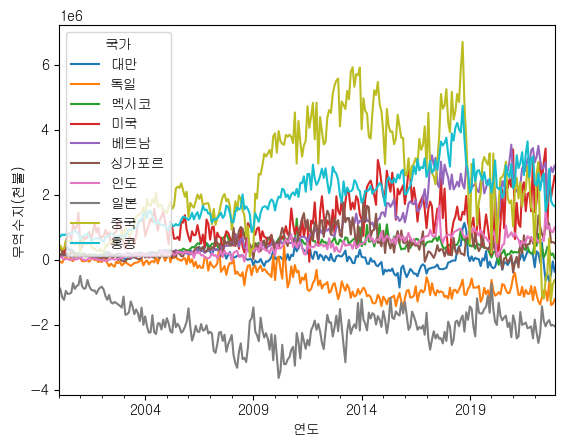

In [6]:
from matplotlib import font_manager, rc

font_path = 'C:\\Windows\\Fonts\\Gulim.ttc'
font = font_manager.FontProperties(fname = font_path).get_name()
rc('font',family = font)

df_import_stacked.plot()
plt.xlabel('연도')
plt.ylabel('무역수지(천불)')
plt.show()

다음은 `read_csv()`를 사용하여 데이터를 가져오는 코드이다. CSV 파일은 케글(https://www.kaggle.com)에서 제공하는 미국의 금 시세 데이터이다. 이 데이터는 앞선 국가별 수출입 현황 통계와는 달리 일별 날짜 열이 포함되어 있기 때문에 앞서 설명한 'parse_dates'와 'index_col'을 사용하여 날짜열을 생성하고 인덱스로 설정하였다. 

In [7]:
df_gold = pd.read_csv('./gold.csv', parse_dates = ['Date'], index_col = 'Date')

In [8]:
df_gold.head()

,Open,High,Low,Close,Volume,Currency
Date,,,,,,
2000-01-04,289.5,289.5,280.0,283.7,21621,USD
2000-01-05,283.7,285.0,281.0,282.1,25448,USD
2000-01-06,281.6,282.8,280.2,282.4,19055,USD
2000-01-07,282.5,284.5,282.0,282.9,11266,USD
2000-01-10,282.4,283.9,281.8,282.7,30603,USD


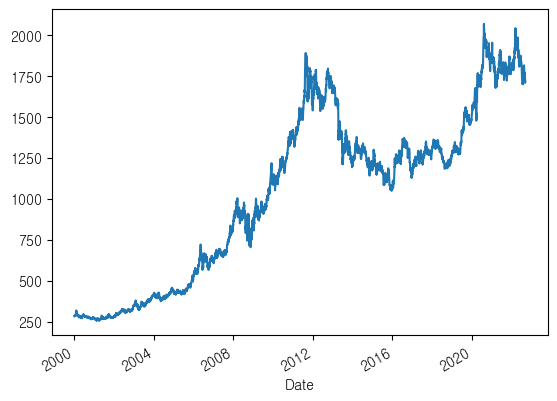

In [9]:
df_gold.Close.plot()
plt.show()